In [9]:
import sys

# Google Colab 환경에서 실행 중인지 확인
if 'google.colab' in sys.modules:
    # debconf를 Noninteractive 모드로 설정
    !echo 'debconf debconf/frontend select Noninteractive' | \
    debconf-set-selections
    # fonts-nanum 패키지를 설치
    !sudo apt-get -qq -y install fonts-nanum

    # Matplotlib의 폰트 매니저 가져오기
    import matplotlib.font_manager as fm

    # 나눔 폰트의 시스템 경로 찾기
    font_files = fm.findSystemFonts(fontpaths=['/usr/share/fonts/truetype/nanum'])

    # 찾은 각 나눔 폰트를 Matplotlib 폰트 매니저에 추가
    for fpath in font_files:
        fm.fontManager.addfont(fpath)

In [10]:
# 필요한 패키지
import numpy as np
import matplotlib.pyplot as plt

import scipy
from scipy import linalg as la
import scipy.stats as ss
import scipy.special

# 한글출력
plt.rcParams['font.family'] = 'Malgun Gothic' #  Windows 'Malgun Gothic' 
plt.rcParams['axes.unicode_minus'] = False

# 필요한 패키지 2
from pgmpy.factors.discrete import JointProbabilityDistribution as JPD
import sympy

scipy.__version__

'1.15.3'

In [17]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# 데이터 로딩
data = yf.download("AAPL", start="2020-01-01", end="2021-01-01")
data.columns = data.columns.droplevel(1)
data

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2020-01-02,72.620842,72.681289,71.373218,71.627092,135480400
2020-01-03,71.914818,72.676447,71.689957,71.847118,146322800
2020-01-06,72.487846,72.526533,70.783248,71.034709,118387200
2020-01-07,72.146942,72.753823,71.926915,72.497529,108872000
2020-01-08,73.307533,73.609768,71.849555,71.849555,132079200
...,...,...,...,...,...
2020-12-24,128.736969,130.190472,127.888287,128.102899,54930100
2020-12-28,133.341339,133.975409,130.239236,130.707487,124486200
2020-12-29,131.565933,135.389899,131.048918,134.668037,121047300


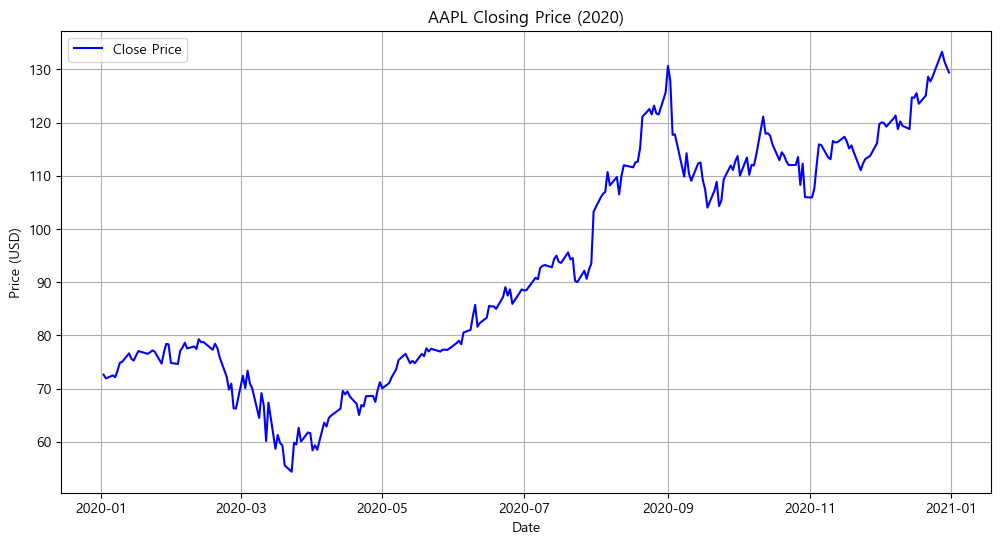

In [31]:
plt.figure(figsize=(12,6))
plt.plot(data['Close'], label = 'Close Price', color='blue')
plt.title("AAPL Closing Price (2020)")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.show()

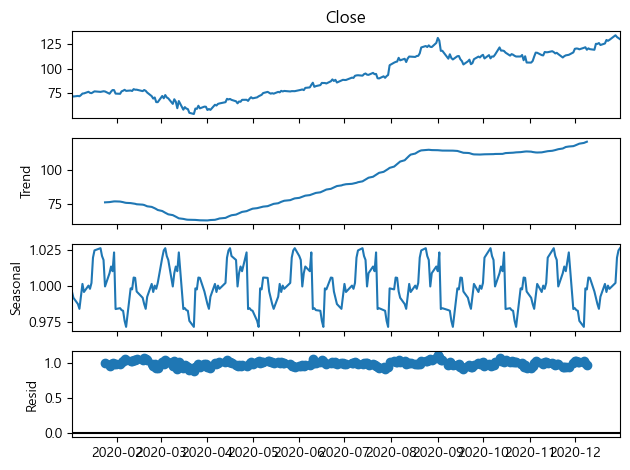

In [27]:
from statsmodels.tsa.seasonal import seasonal_decompose

# 종가 기준으로 시계열 분해 (추세, 계절성, 잔차)
result = seasonal_decompose(data['Close'], model='multiplicative', period=30)
result.plot()
plt.show()

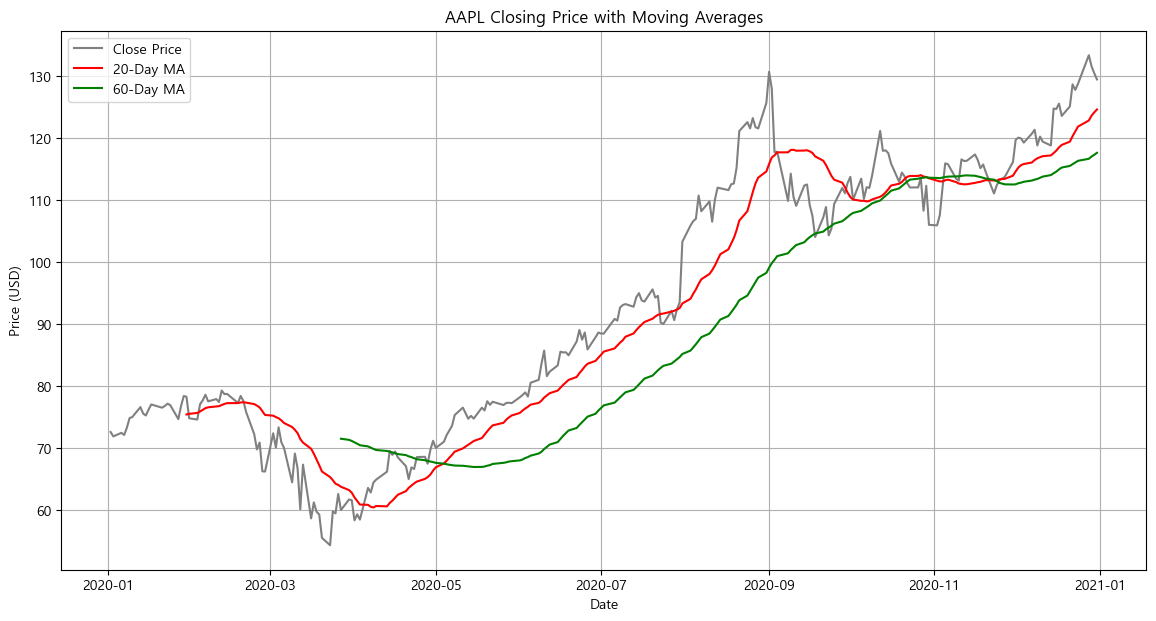

In [26]:
# 20일, 60일 이동평균 추가
data['MA20'] = data['Close'].rolling(window=20).mean()
data['MA60'] = data['Close'].rolling(window=60).mean()

# 시각화
plt.figure(figsize=(14, 7))
plt.plot(data['Close'], label='Close Price', color='gray')
plt.plot(data['MA20'], label='20-Day MA', color='red')
plt.plot(data['MA60'], label='60-Day MA', color='green')
plt.title("AAPL Closing Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.show()

### 데이터셋 설정

### P,D,Q 찾기